In [1]:
print("=" * 60)
print("GRADIENT BOOSTING FROM SCRATCH")
print("=" * 60)

# These are standard Python libraries we need.
# numpy: for math and arrays
# matplotlib: for plotting graphs
# DecisionTreeRegressor: one single decision tree (our "weak learner")
# train_test_split: splits data into training and testing portions
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

# ============================================
# SIMPLE GRADIENT BOOSTING IMPLEMENTATION
# ============================================

# WHAT IS GRADIENT BOOSTING?
# Imagine you're trying to guess someone's age from a photo.
# Your first guess might be "35" (just an average).
# Then you look at the error: you were 5 years off.
# Your second guess focuses on correcting that 5-year mistake.
# Your third guess corrects whatever error is left.
# Gradient boosting does exactly this — each tree fixes the
# mistakes of all the trees before it.

class SimpleGradientBoosting:
    """
    Simple Gradient Boosting for Regression
    
    Core idea: Each tree predicts residuals (errors) from previous trees
    
    Parameters:
        n_estimators: Number of boosting rounds (trees)
        learning_rate: Shrinkage parameter (0-1)
        max_depth: Maximum depth of each tree
    """
    
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators   # how many trees to build
        self.learning_rate = learning_rate  # how much each tree contributes (small = safer)
        self.max_depth = max_depth          # how deep each tree can grow (shallow = simpler)
        
        self.trees = []               # we'll store every trained tree here
        self.init_prediction = None   # our very first guess before any trees
        
        # keeps a record of the error after each tree is added
        self.training_errors = []
    
    def fit(self, X, y, verbose=True):
        """
        Train gradient boosting model
        
        Algorithm:
        1. Start with initial prediction (mean)
        2. For each boosting round:
           a. Compute residuals (errors)
           b. Train tree to predict residuals
           c. Add tree to ensemble with learning_rate
        """
        # STEP 1: Our initial guess is just the average of all target values.
        # This is the simplest possible prediction — if we know nothing else,
        # predicting the mean minimizes overall squared error.
        self.init_prediction = np.mean(y)
        
        if verbose:
            print(f"\nInitial prediction (mean): {self.init_prediction:.2f}")
        
        # Every sample starts with the same prediction: the overall mean.
        current_predictions = np.full(len(y), self.init_prediction)
        
        # STEP 2: Now we iteratively improve by training one tree at a time.
        for i in range(self.n_estimators):
            # RESIDUALS = how wrong are we right now?
            # If y=10 and we predicted 8, the residual is +2 (we need to go up by 2).
            # The next tree will try to predict these residuals directly.
            residuals = y - current_predictions
            
            # Train a shallow decision tree to predict the residuals.
            # Shallow trees (small max_depth) are "weak learners" — they only
            # capture a little bit of the pattern. That's intentional!
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                random_state=i
            )
            tree.fit(X, residuals)
            
            # Ask the new tree: how much should we adjust our predictions?
            tree_predictions = tree.predict(X)
            
            # KEY IDEA — learning rate (η):
            # Instead of fully trusting this tree, we only take a small step
            # in its direction. This prevents overshooting and overfitting.
            # Think of it like carefully inching toward the answer instead of
            # jumping all the way there in one leap.
            current_predictions += self.learning_rate * tree_predictions
            
            # Save the tree so we can use it later during prediction.
            self.trees.append(tree)
            
            # Track mean squared error to see how we're improving.
            mse = np.mean((y - current_predictions) ** 2)
            self.training_errors.append(mse)
            
            if verbose and (i + 1) % 20 == 0:
                print(f"Tree {i+1}: MSE = {mse:.4f}, "
                      f"Mean residual = {np.mean(np.abs(residuals)):.4f}")
        
        if verbose:
            print(f"\n✓ Training complete!")
            print(f"Final MSE: {self.training_errors[-1]:.4f}")
        
        return self
    
    def predict(self, X):
        """
        Make predictions by summing all tree predictions
        
        Formula: F(x) = F₀ + η·T₁(x) + η·T₂(x) + ... + η·Tₙ(x)
        
        We start from the initial mean and then add every tree's
        small correction on top. It's like stacking layers of
        improvements one at a time.
        """
        # Start from the baseline guess (mean of training targets).
        predictions = np.full(len(X), self.init_prediction)
        
        # Each tree contributes a small correction (scaled by learning_rate).
        for tree in self.trees:
            predictions += self.learning_rate * tree.predict(X)
        
        return predictions
    
    def predict_step_by_step(self, X, steps=None):
        """
        Return predictions at each boosting round.
        
        Useful for visualization — lets us see how predictions evolve
        as we add more and more trees. After 0 trees: flat line (mean).
        After 50 trees: much closer to the true curve.
        """
        if steps is None:
            steps = len(self.trees)
        
        all_predictions = []
        predictions = np.full(len(X), self.init_prediction)
        all_predictions.append(predictions.copy())
        
        for i, tree in enumerate(self.trees[:steps]):
            predictions += self.learning_rate * tree.predict(X)
            all_predictions.append(predictions.copy())
        
        return all_predictions

print("\n✓ SimpleGradientBoosting class implemented!")

GRADIENT BOOSTING FROM SCRATCH

✓ SimpleGradientBoosting class implemented!



VISUALIZING THE BOOSTING PROCESS
Dataset: 100 samples

Initial prediction (mean): 2.65
Tree 20: MSE = 0.0931, Mean residual = 0.2643
Tree 40: MSE = 0.0340, Mean residual = 0.1454

✓ Training complete!
Final MSE: 0.0275


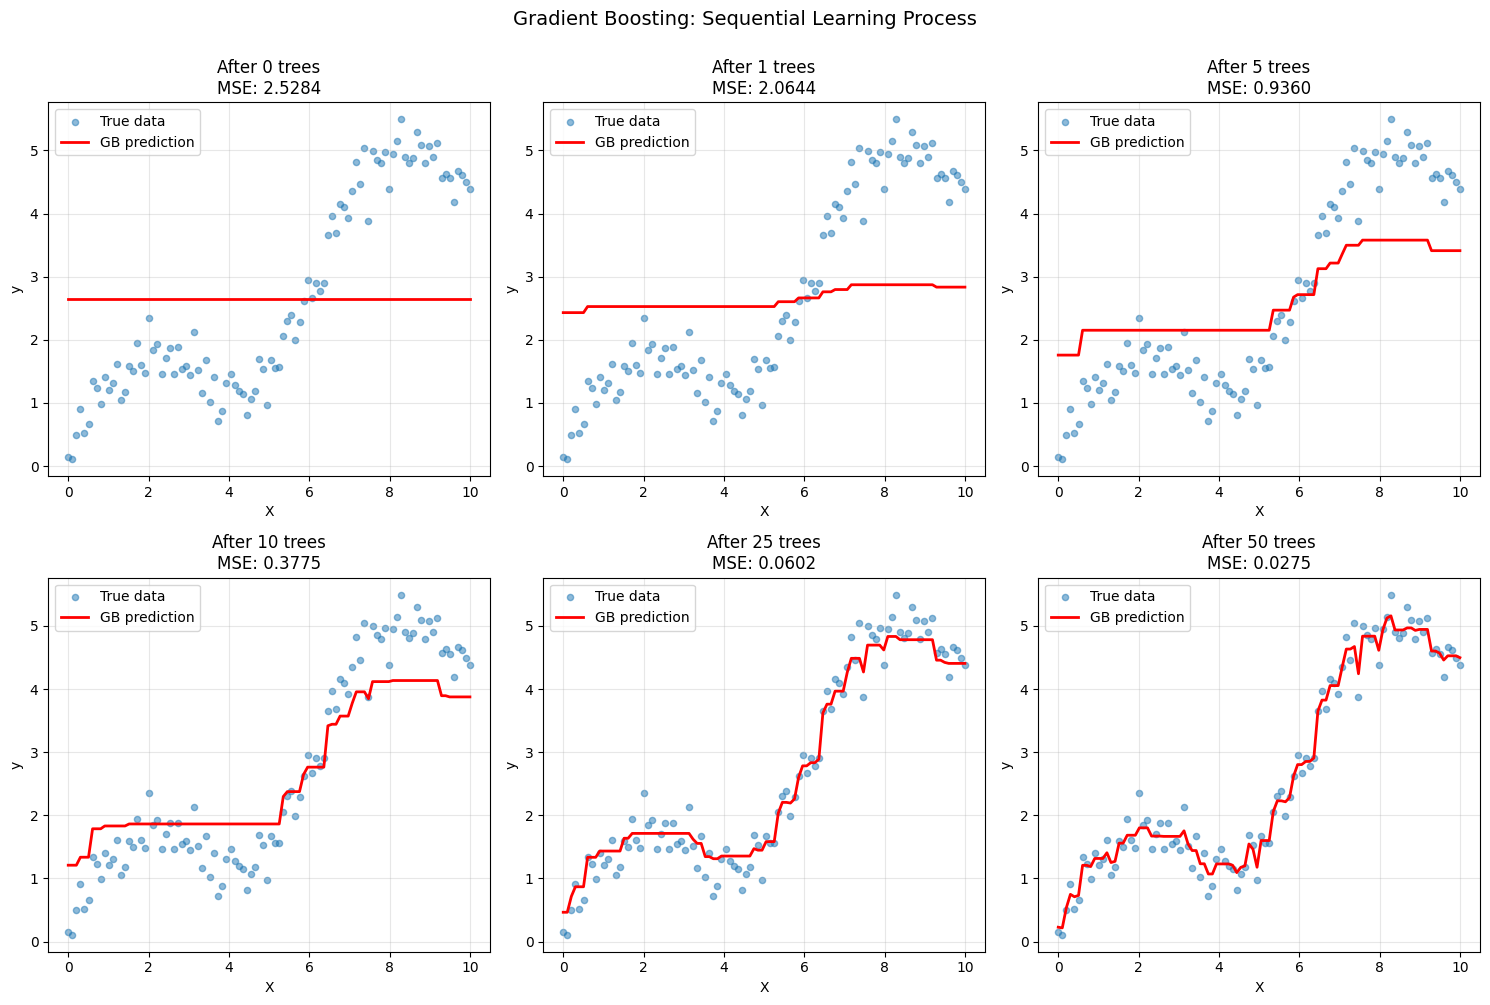


✓ See how predictions improve with each tree!


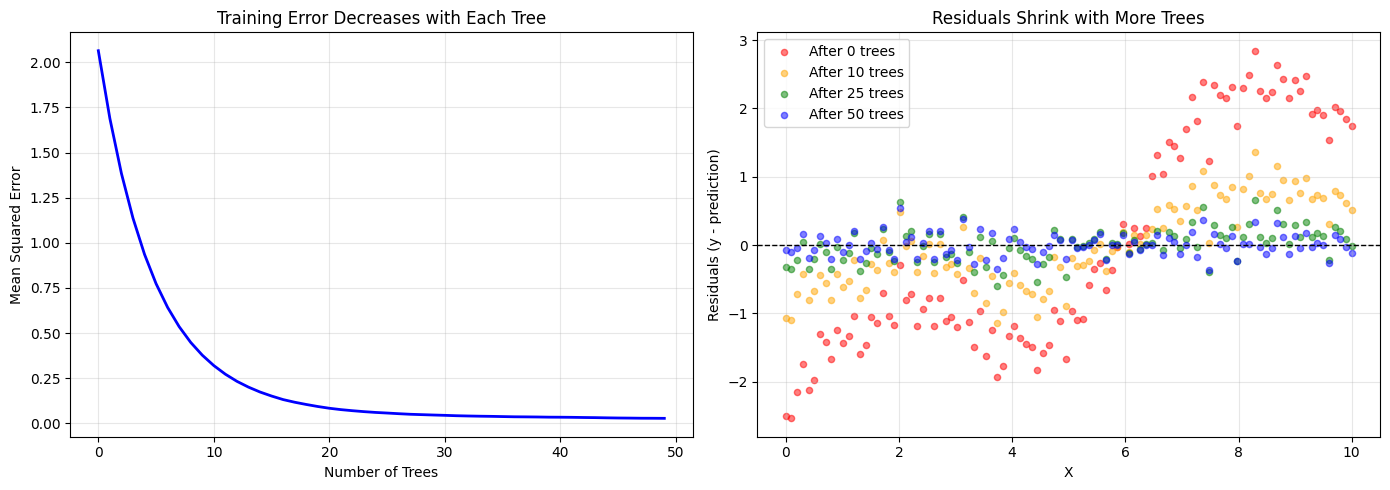


✓ Residuals get smaller and smaller!
  This is the power of sequential correction!


In [2]:
print("\n" + "=" * 60)
print("VISUALIZING THE BOOSTING PROCESS")
print("=" * 60)

# Create a synthetic dataset with a non-linear (wavy) pattern.
# np.random.seed(42) ensures we get the same "random" data every time we run.
np.random.seed(42)
X_simple = np.linspace(0, 10, 100).reshape(-1, 1)  # 100 evenly-spaced X values from 0 to 10
# y = sine wave + upward trend + small random noise
y_simple = np.sin(X_simple.ravel()) + 0.5 * X_simple.ravel() + np.random.randn(100) * 0.3

print(f"Dataset: {len(X_simple)} samples")

# Train our gradient boosting model.
# low learning_rate=0.1 means each tree makes only small adjustments —
# the model learns slowly but steadily.
gb_viz = SimpleGradientBoosting(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3
)

gb_viz.fit(X_simple, y_simple, verbose=True)

# Capture the model's predictions after 0, 1, 2, ... 50 trees.
# This lets us "replay" the learning process for the visualization below.
predictions_at_stages = gb_viz.predict_step_by_step(X_simple)

# ============================================
# VISUALIZATION 1: Boosting Progress
# ============================================
# We'll show 6 snapshots of the model at different stages.
# Notice how the red prediction line starts flat (just the mean)
# and gradually bends to match the true data.

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
stages = [0, 1, 5, 10, 25, 50]  # number of trees used at each snapshot

for idx, stage in enumerate(stages):
    ax = axes[idx // 3, idx % 3]
    
    # Plot the actual data points as a scatter.
    ax.scatter(X_simple, y_simple, alpha=0.5, s=20, label='True data')
    
    # Plot the model's prediction at this stage.
    preds = predictions_at_stages[stage]
    ax.plot(X_simple, preds, 'r-', linewidth=2, label='GB prediction')
    
    # Compute MSE — lower is better.
    residuals = y_simple - preds
    mse = np.mean(residuals ** 2)
    
    ax.set_title(f'After {stage} trees\nMSE: {mse:.4f}', fontsize=12)
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Gradient Boosting: Sequential Learning Process', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print("\n✓ See how predictions improve with each tree!")

# ============================================
# VISUALIZATION 2: Residuals Shrinking
# ============================================
# As we add more trees, the errors (residuals) get smaller and closer to 0.
# The left chart shows the MSE dropping over iterations.
# The right chart shows that the scatter of residuals tightens around the
# horizontal zero line — meaning our predictions are getting more accurate.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: MSE over each boosting round.
ax1.plot(range(len(gb_viz.training_errors)), gb_viz.training_errors, 
         'b-', linewidth=2)
ax1.set_xlabel('Number of Trees')
ax1.set_ylabel('Mean Squared Error')
ax1.set_title('Training Error Decreases with Each Tree')
ax1.grid(True, alpha=0.3)

# Right plot: scatter of residuals at 4 different stages.
# Residuals should shrink toward zero as the model improves.
stages_to_show = [0, 10, 25, 50]
colors = ['red', 'orange', 'green', 'blue']

for stage, color in zip(stages_to_show, colors):
    preds = predictions_at_stages[stage]
    residuals = y_simple - preds
    
    ax2.scatter(X_simple, residuals, alpha=0.5, s=20, 
                color=color, label=f'After {stage} trees')

# A flat line at y=0 means perfect predictions — the closer the dots get
# to this line, the better our model is doing.
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('X')
ax2.set_ylabel('Residuals (y - prediction)')
ax2.set_title('Residuals Shrink with More Trees')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Residuals get smaller and smaller!")
print("  This is the power of sequential correction!")


LEARNING RATE EFFECT

Trying learning_rate=1.0...

Trying learning_rate=0.5...

Trying learning_rate=0.1...

Trying learning_rate=0.01...


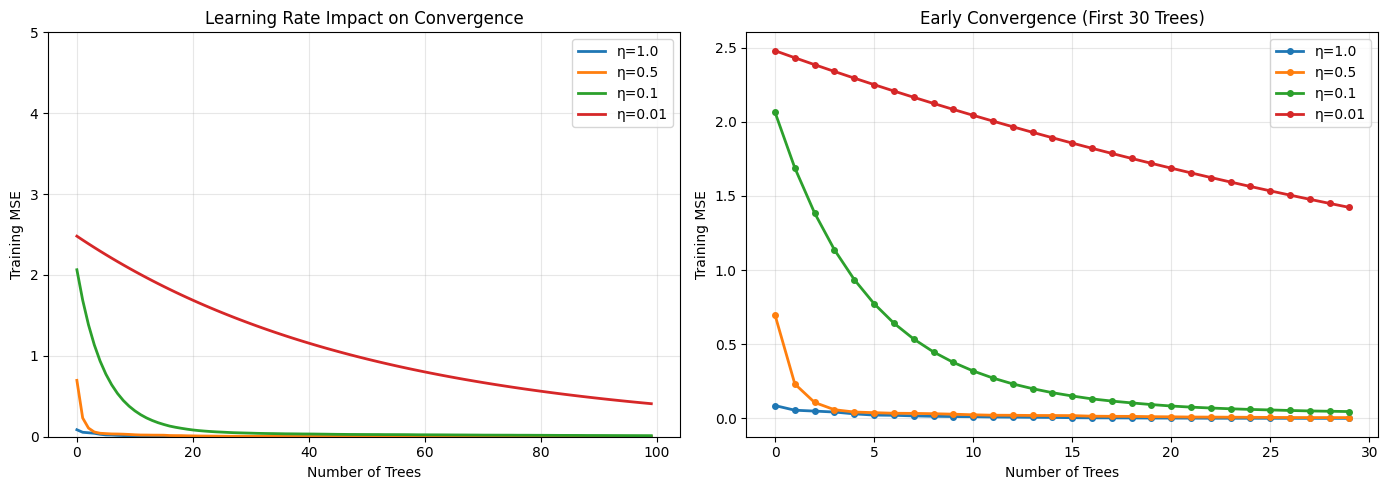


LEARNING RATE INSIGHTS:

η = 1.0 (High):
  • Fast initial drop
  • But unstable (can overshoot)
  • May not converge smoothly

η = 0.5 (Moderate):
  • Good balance
  • Reasonably fast
  • More stable

η = 0.1 (Standard):
  • Slower but smooth
  • Very stable
  • Most commonly used

η = 0.01 (Low):
  • Very slow
  • Needs many more trees
  • Might not fully converge in 100 trees

RULE OF THUMB:
  Small η → More trees needed, but better generalization
  Large η → Fewer trees needed, but risk overfitting

  Typical: η = 0.1 with 100-500 trees



In [3]:
print("\n" + "=" * 60)
print("LEARNING RATE EFFECT")
print("=" * 60)

# WHAT IS THE LEARNING RATE?
# The learning rate (η, "eta") controls how large a step each tree takes.
#
# Think of it like walking downhill to find the lowest point in a valley:
#   - Big steps (high η): you get there fast, but might overshoot the bottom.
#   - Small steps (low η): you approach slowly, but land more precisely.
#
# In gradient boosting: a smaller learning rate requires more trees to
# converge, but usually generalizes better to unseen data.

learning_rates = [1.0, 0.5, 0.1, 0.01]
results = {}

for lr in learning_rates:
    print(f"\nTrying learning_rate={lr}...")
    
    gb = SimpleGradientBoosting(
        n_estimators=100,
        learning_rate=lr,
        max_depth=3
    )
    
    gb.fit(X_simple, y_simple, verbose=False)
    results[lr] = gb.training_errors  # store MSE history for each lr

# ============================================
# VISUALIZATION: How learning rate affects convergence
# ============================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: full 100-tree MSE curves for each learning rate.
for lr in learning_rates:
    ax1.plot(results[lr], label=f'η={lr}', linewidth=2)

ax1.set_xlabel('Number of Trees')
ax1.set_ylabel('Training MSE')
ax1.set_title('Learning Rate Impact on Convergence')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, max([max(results[1.0][:20]), 5]))  # zoom in to first 20 trees

# Right plot: first 30 trees only — easier to see early behavior.
for lr in learning_rates:
    ax2.plot(results[lr][:30], label=f'η={lr}', linewidth=2, marker='o', markersize=4)

ax2.set_xlabel('Number of Trees')
ax2.set_ylabel('Training MSE')
ax2.set_title('Early Convergence (First 30 Trees)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("LEARNING RATE INSIGHTS:")
print("=" * 60)
print("""
η = 1.0 (High):
  • Fast initial drop
  • But unstable (can overshoot)
  • May not converge smoothly
  
η = 0.5 (Moderate):
  • Good balance
  • Reasonably fast
  • More stable
  
η = 0.1 (Standard):
  • Slower but smooth
  • Very stable
  • Most commonly used
  
η = 0.01 (Low):
  • Very slow
  • Needs many more trees
  • Might not fully converge in 100 trees
  
RULE OF THUMB:
  Small η → More trees needed, but better generalization
  Large η → Fewer trees needed, but risk overfitting
  
  Typical: η = 0.1 with 100-500 trees
""")


RANDOM FOREST vs GRADIENT BOOSTING COMPARISON
Training: 800 samples
Test: 200 samples

RANDOM FOREST
Training time: 0.213 seconds
Training MSE: 0.1796, R²: 0.9745
Test MSE: 2.2032, R²: 0.7854
Overfitting gap: 0.1890

GRADIENT BOOSTING (Our Implementation)
Training time: 0.385 seconds
Training MSE: 0.5318, R²: 0.9245
Test MSE: 1.7894, R²: 0.8257
Overfitting gap: 0.0987

HEAD-TO-HEAD COMPARISON
       Metric Random Forest Gradient Boosting
Training Time        0.213s            0.385s
     Train R²        0.9745            0.9245
      Test R²        0.7854            0.8257
  Overfit Gap        0.1890            0.0987
   Tree Depth     Unlimited                 3

KEY OBSERVATIONS:

1. SPEED:
   Random Forest: 0.213s (FASTER ⚡)
   Gradient Boosting: 0.385s (slower)
   → RF trains 1.8x faster (parallel!)

2. ACCURACY:
   Test R² comparison shows which generalizes better

3. TREE DEPTH:
   RF: Deep trees (unlimited)
   GB: Shallow trees (depth=3)
   → GB achieves similar/better with sim

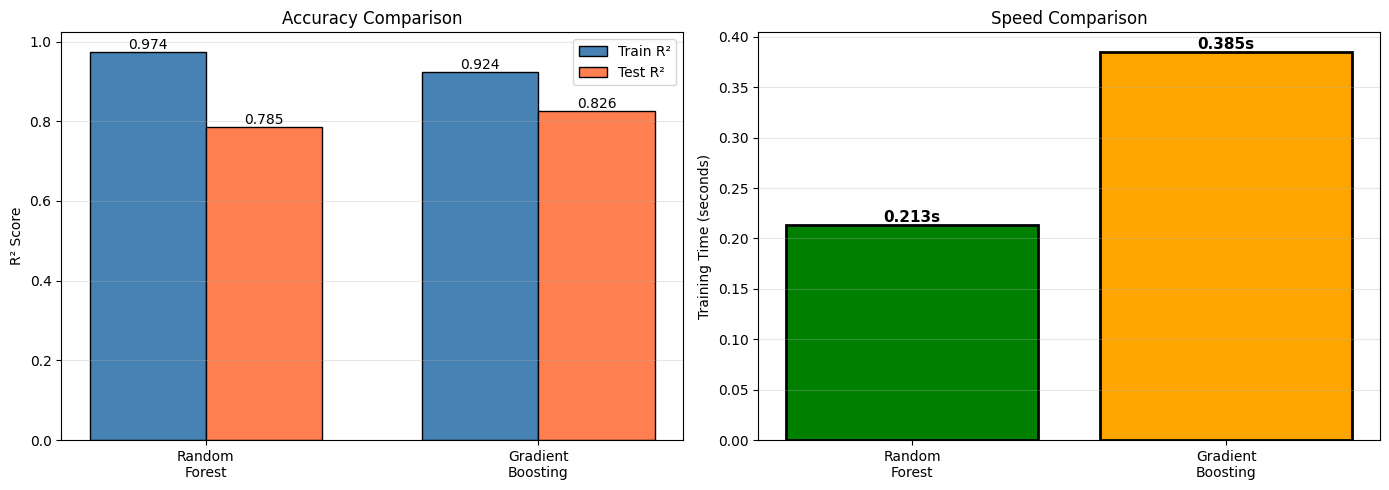


✓ Comparison complete!


In [4]:
import pandas as pd

print("\n" + "=" * 60)
print("RANDOM FOREST vs GRADIENT BOOSTING COMPARISON")
print("=" * 60)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time

# QUICK RECAP — two very different ensemble strategies:
#
# RANDOM FOREST: builds many independent trees in PARALLEL,
#   each trained on a random subset of data & features.
#   Final answer = average of all trees.
#   Think: "wisdom of the crowd" — many independent opinions.
#
# GRADIENT BOOSTING: builds trees SEQUENTIALLY,
#   where each tree corrects the errors of the previous one.
#   Think: "learning from your mistakes" — one focused expert
#   that keeps self-correcting.

# Generate a dataset with a non-linear relationship between features and target.
np.random.seed(42)
X = np.random.randn(1000, 10)  # 1000 samples, each with 10 features
# Complex target: involves squaring, sine, and interactions between features.
# This is intentionally non-linear to challenge both models.
y = (X[:, 0] ** 2 + np.sin(X[:, 1]) * 3 + 
     X[:, 2] * X[:, 3] + np.random.randn(1000) * 0.5)

# Split into training set (80%) and test set (20%).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")

# ============================================
# RANDOM FOREST
# ============================================

print("\n" + "=" * 60)
print("RANDOM FOREST")
print("=" * 60)

start = time.time()  # start a timer to measure training speed

# max_depth=None means trees can grow as deep as they want.
# n_jobs=-1 uses all CPU cores in parallel — this is why RF is so fast!
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_time = time.time() - start  # how long training took

# Evaluate on both train and test sets.
# A big gap between train and test scores means the model is overfitting
# (memorizing training data but failing to generalize).
rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

rf_train_mse = mean_squared_error(y_train, rf_train_pred)
rf_test_mse = mean_squared_error(y_test, rf_test_pred)
rf_train_r2 = r2_score(y_train, rf_train_pred)  # R² = 1.0 is perfect, 0.0 = no better than mean
rf_test_r2 = r2_score(y_test, rf_test_pred)

print(f"Training time: {rf_time:.3f} seconds")
print(f"Training MSE: {rf_train_mse:.4f}, R²: {rf_train_r2:.4f}")
print(f"Test MSE: {rf_test_mse:.4f}, R²: {rf_test_r2:.4f}")
print(f"Overfitting gap: {rf_train_r2 - rf_test_r2:.4f}")  # smaller is better

# ============================================
# GRADIENT BOOSTING (Our Implementation)
# ============================================

print("\n" + "=" * 60)
print("GRADIENT BOOSTING (Our Implementation)")
print("=" * 60)

start = time.time()

# Note: max_depth=3 — very shallow trees!
# GB works well with weak learners (shallow trees) because each tree only
# needs to correct a small piece of the remaining error.
gb = SimpleGradientBoosting(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3
)

gb.fit(X_train, y_train, verbose=False)
gb_time = time.time() - start

gb_train_pred = gb.predict(X_train)
gb_test_pred = gb.predict(X_test)

gb_train_mse = mean_squared_error(y_train, gb_train_pred)
gb_test_mse = mean_squared_error(y_test, gb_test_pred)
gb_train_r2 = r2_score(y_train, gb_train_pred)
gb_test_r2 = r2_score(y_test, gb_test_pred)

print(f"Training time: {gb_time:.3f} seconds")
print(f"Training MSE: {gb_train_mse:.4f}, R²: {gb_train_r2:.4f}")
print(f"Test MSE: {gb_test_mse:.4f}, R²: {gb_test_r2:.4f}")
print(f"Overfitting gap: {gb_train_r2 - gb_test_r2:.4f}")

# ============================================
# COMPARISON
# ============================================

print("\n" + "=" * 60)
print("HEAD-TO-HEAD COMPARISON")
print("=" * 60)

# Build a summary table so it's easy to compare side by side.
comparison = pd.DataFrame({
    'Metric': ['Training Time', 'Train R²', 'Test R²', 'Overfit Gap', 'Tree Depth'],
    'Random Forest': [
        f'{rf_time:.3f}s',
        f'{rf_train_r2:.4f}',
        f'{rf_test_r2:.4f}',
        f'{rf_train_r2 - rf_test_r2:.4f}',
        'Unlimited'
    ],
    'Gradient Boosting': [
        f'{gb_time:.3f}s',
        f'{gb_train_r2:.4f}',
        f'{gb_test_r2:.4f}',
        f'{gb_train_r2 - gb_test_r2:.4f}',
        '3'
    ]
})

print(comparison.to_string(index=False))

print("\n" + "=" * 60)
print("KEY OBSERVATIONS:")
print("=" * 60)
print(f"""
1. SPEED:
   Random Forest: {rf_time:.3f}s (FASTER ⚡)
   Gradient Boosting: {gb_time:.3f}s (slower)
   → RF trains {gb_time/rf_time:.1f}x faster (parallel!)

2. ACCURACY:
   Test R² comparison shows which generalizes better
   
3. TREE DEPTH:
   RF: Deep trees (unlimited)
   GB: Shallow trees (depth=3)
   → GB achieves similar/better with simpler trees!

4. OVERFITTING:
   Smaller gap = Better generalization
""")

# ============================================
# BAR CHART COMPARISON
# ============================================
# Two bar charts: one for accuracy (R²), one for training speed.
# Blue bars = training score, coral bars = test score.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models = ['Random\nForest', 'Gradient\nBoosting']
train_scores = [rf_train_r2, gb_train_r2]
test_scores = [rf_test_r2, gb_test_r2]

x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, train_scores, width, label='Train R²', 
                color='steelblue', edgecolor='black')
bars2 = ax1.bar(x + width/2, test_scores, width, label='Test R²', 
                color='coral', edgecolor='black')

ax1.set_ylabel('R² Score')
ax1.set_title('Accuracy Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()
ax1.grid(True, axis='y', alpha=0.3)

# Add the numeric values above each bar for readability.
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

times = [rf_time, gb_time]
colors = ['green', 'orange']

bars = ax2.bar(models, times, color=colors, edgecolor='black', linewidth=2)
ax2.set_ylabel('Training Time (seconds)')
ax2.set_title('Speed Comparison')
ax2.grid(True, axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Comparison complete!")

In [5]:
# Install the XGBoost library.
# XGBoost (eXtreme Gradient Boosting) is a highly optimized, production-ready
# implementation of gradient boosting. It's much faster than our from-scratch
# version and adds extra features like built-in regularization and early stopping.
# The %pip magic ensures it installs into the same Python environment as the notebook.
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



XGBOOST - THE OPTIMIZED IMPLEMENTATION
XGBoost version: 3.2.0

Training XGBoost
Training time: 0.305 seconds
Training MSE: 0.5899, R²: 0.9162
Test MSE: 1.9797, R²: 0.8072
Overfitting gap: 0.1090

THREE-WAY COMPARISON
       Metric Random Forest Our GB XGBoost
Training Time        0.213s 0.385s  0.305s
     Train R²        0.9745 0.9245  0.9162
      Test R²        0.7854 0.8257  0.8072
  Overfit Gap        0.1890 0.0987  0.1090

KEY INSIGHTS:

1. SPEED RANKING:
   Random Forest: 0.213s (FASTEST - parallel)
   XGBoost: 0.305s (middle - optimized sequential)
   Our GB: 0.385s (slowest - basic sequential)

   → XGBoost is 1.3x faster than our implementation!
   → But RF still 1.4x faster than XGBoost

2. ACCURACY:
   All three perform similarly on this dataset
   XGBoost often slightly better with tuning

3. WHY XGBOOST IS POPULAR:
   • Much faster than basic GB (1.3x speedup)
   • Better accuracy potential
   • Built-in regularization
   • Production features (early stopping, etc.)



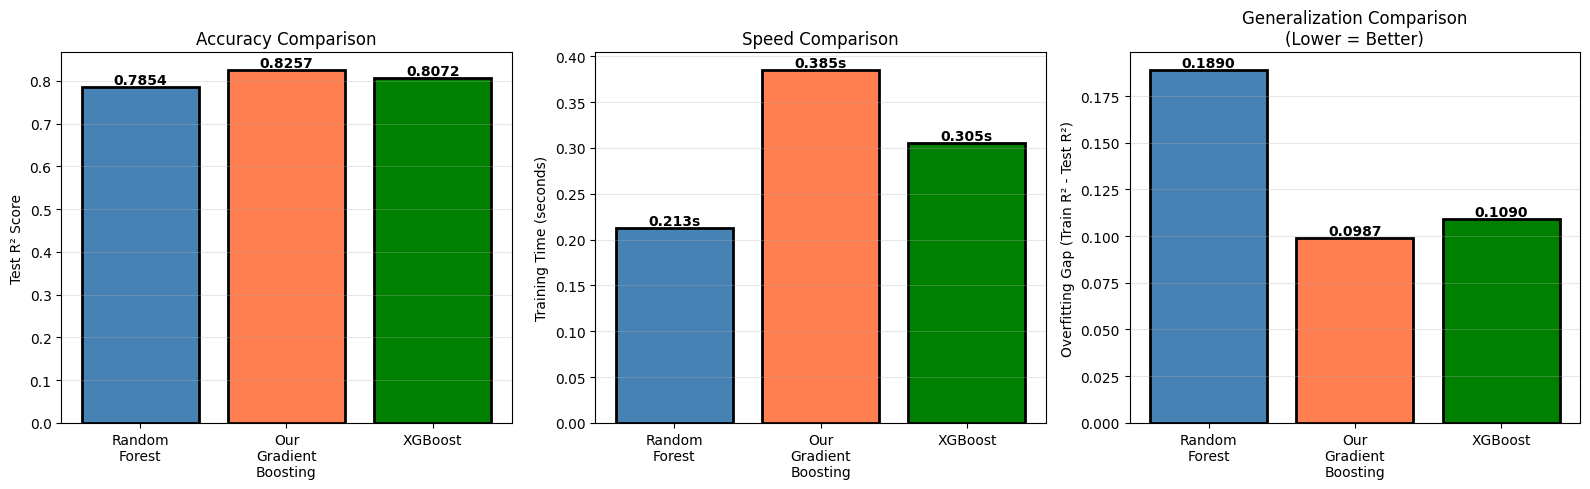


✓ XGBoost introduction complete!


In [6]:
print("\n" + "=" * 60)
print("XGBOOST - THE OPTIMIZED IMPLEMENTATION")
print("=" * 60)

# WHY XGBOOST?
# Our SimpleGradientBoosting works, but it's slow and basic.
# XGBoost is the same idea but engineered for real-world use:
#   • Parallelized tree building (faster)
#   • Built-in L1/L2 regularization (prevents overfitting)
#   • Handles missing values automatically
#   • Early stopping support
#   • Used by winners of hundreds of Kaggle competitions!

import xgboost as xgb

print("XGBoost version:", xgb.__version__)

# ============================================
# XGBOOST TRAINING
# ============================================

print("\n" + "=" * 60)
print("Training XGBoost")
print("=" * 60)

start = time.time()

# XGBRegressor has the same sklearn-style API (.fit, .predict, .score)
# as our SimpleGradientBoosting, making it easy to swap in.
# We use the same hyperparameters as our scratch version for a fair comparison.
xgb_model = xgb.XGBRegressor(
    n_estimators=100,    # same as our model
    learning_rate=0.1,   # same as our model
    max_depth=3,         # same as our model
    random_state=42,
    n_jobs=-1            # use all CPU cores — XGBoost can parallelize!
)

xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start

xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

xgb_train_mse = mean_squared_error(y_train, xgb_train_pred)
xgb_test_mse = mean_squared_error(y_test, xgb_test_pred)
xgb_train_r2 = r2_score(y_train, xgb_train_pred)
xgb_test_r2 = r2_score(y_test, xgb_test_pred)

print(f"Training time: {xgb_time:.3f} seconds")
print(f"Training MSE: {xgb_train_mse:.4f}, R²: {xgb_train_r2:.4f}")
print(f"Test MSE: {xgb_test_mse:.4f}, R²: {xgb_test_r2:.4f}")
print(f"Overfitting gap: {xgb_train_r2 - xgb_test_r2:.4f}")

# ============================================
# THREE-WAY COMPARISON
# ============================================
# Now we compare all three: RF, our scratch GB, and XGBoost.
# This shows clearly what XGBoost adds over a naive implementation.

print("\n" + "=" * 60)
print("THREE-WAY COMPARISON")
print("=" * 60)

comparison_3way = pd.DataFrame({
    'Metric': ['Training Time', 'Train R²', 'Test R²', 'Overfit Gap'],
    'Random Forest': [
        f'{rf_time:.3f}s',
        f'{rf_train_r2:.4f}',
        f'{rf_test_r2:.4f}',
        f'{rf_train_r2 - rf_test_r2:.4f}'
    ],
    'Our GB': [
        f'{gb_time:.3f}s',
        f'{gb_train_r2:.4f}',
        f'{gb_test_r2:.4f}',
        f'{gb_train_r2 - gb_test_r2:.4f}'
    ],
    'XGBoost': [
        f'{xgb_time:.3f}s',
        f'{xgb_train_r2:.4f}',
        f'{xgb_test_r2:.4f}',
        f'{xgb_train_r2 - xgb_test_r2:.4f}'
    ]
})

print(comparison_3way.to_string(index=False))

print("\n" + "=" * 60)
print("KEY INSIGHTS:")
print("=" * 60)
print(f"""
1. SPEED RANKING:
   Random Forest: {rf_time:.3f}s (FASTEST - parallel)
   XGBoost: {xgb_time:.3f}s (middle - optimized sequential)
   Our GB: {gb_time:.3f}s (slowest - basic sequential)
   
   → XGBoost is {gb_time/xgb_time:.1f}x faster than our implementation!
   → But RF still {xgb_time/rf_time:.1f}x faster than XGBoost

2. ACCURACY:
   All three perform similarly on this dataset
   XGBoost often slightly better with tuning

3. WHY XGBOOST IS POPULAR:
   • Much faster than basic GB ({gb_time/xgb_time:.1f}x speedup)
   • Better accuracy potential
   • Built-in regularization
   • Production features (early stopping, etc.)
""")

# ============================================
# THREE-WAY VISUALIZATION
# ============================================
# Three charts: accuracy (Test R²), speed (training time), and
# generalization gap (Train R² - Test R² — lower = better).

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = ['Random\nForest', 'Our\nGradient\nBoosting', 'XGBoost']
test_scores_all = [rf_test_r2, gb_test_r2, xgb_test_r2]
colors = ['steelblue', 'coral', 'green']

# Chart 1: Test R² — higher is better.
bars = axes[0].bar(models, test_scores_all, color=colors, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Test R² Score')
axes[0].set_title('Accuracy Comparison')
axes[0].grid(True, axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Chart 2: Training time — lower is better.
times_all = [rf_time, gb_time, xgb_time]

bars = axes[1].bar(models, times_all, color=colors, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Training Time (seconds)')
axes[1].set_title('Speed Comparison')
axes[1].grid(True, axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Chart 3: Overfitting gap — lower means better generalization.
gaps = [rf_train_r2 - rf_test_r2, gb_train_r2 - gb_test_r2, xgb_train_r2 - xgb_test_r2]

bars = axes[2].bar(models, gaps, color=colors, edgecolor='black', linewidth=2)
axes[2].set_ylabel('Overfitting Gap (Train R² - Test R²)')
axes[2].set_title('Generalization Comparison\n(Lower = Better)')
axes[2].grid(True, axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ XGBoost introduction complete!")

In [7]:
print("=" * 60)
print("XGBOOST HYPERPARAMETER TUNING MASTERCLASS")
print("=" * 60)

# WHAT IS HYPERPARAMETER TUNING?
# Hyperparameters are settings you choose before training (unlike model
# parameters which are learned during training). Tuning means searching
# for the combination that gives the best performance.
#
# Our staged approach:
#   Stage 1 — Baseline: train with defaults to get a starting score.
#   Stage 2 — Core tuning: search n_estimators, learning_rate, max_depth.
#   Stage 3 — Regularization: if overfitting is detected, add constraints.
#   Stage 4 — Final evaluation: report scores on the held-out test set.

import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, r2_score
import time

# make_regression creates a synthetic dataset well-suited for regression tasks.
# n_informative=30 means only 30 of the 50 features are actually useful —
# this makes tuning more realistic (not all features matter in real data).
np.random.seed(42)
X, y = make_regression(
    n_samples=2000,
    n_features=50,
    n_informative=30,
    noise=10,
    random_state=42
)

# Three-way split: train (to fit), validation (to tune), test (final score).
# NEVER use the test set to make tuning decisions — it should be touched once.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Training: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

# ============================================
# STAGE 1: BASELINE (Defaults)
# ============================================
# Always start with default parameters to have a score to beat.
# If defaults already perform well, tuning may not be worth the time.

print("\n" + "=" * 60)
print("STAGE 1: Baseline Model (Defaults)")
print("=" * 60)

xgb_baseline = xgb.XGBRegressor(
    random_state=42,
    n_jobs=-1
)

xgb_baseline.fit(X_train, y_train)

baseline_train = xgb_baseline.score(X_train, y_train)
baseline_val = xgb_baseline.score(X_val, y_val)

print(f"Train R²: {baseline_train:.4f}")
print(f"Val R²: {baseline_val:.4f}")
print(f"Gap: {baseline_train - baseline_val:.4f}")

# ============================================
# STAGE 2: TUNE CORE PARAMETERS (Tier 1)
# ============================================
# GridSearchCV tries every combination of parameters listed and uses
# cross-validation (cv=3 = 3-fold CV) to estimate the true performance
# of each combination. It then returns the best one automatically.
#
# Key parameters to tune first:
#   n_estimators: more trees = more learning rounds
#   learning_rate: step size per tree (smaller = safer but slower)
#   max_depth: tree complexity (deeper = more expressive but overfits faster)

print("\n" + "=" * 60)
print("STAGE 2: Tuning Core Parameters")
print("=" * 60)

param_grid_core = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 4, 6]
}

print(f"Grid size: {3*3*3} = 27 combinations")

grid_core = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_grid_core,
    cv=3,           # 3-fold cross-validation for each combination
    scoring='r2',   # optimize for R² score
    n_jobs=-1,      # run combinations in parallel
    verbose=1
)

print("\nSearching...")
grid_core.fit(X_train, y_train)

print(f"\nBest params: {grid_core.best_params_}")
print(f"Best CV R²: {grid_core.best_score_:.4f}")

core_train = grid_core.score(X_train, y_train)
core_val = grid_core.score(X_val, y_val)

print(f"Train R²: {core_train:.4f}")
print(f"Val R²: {core_val:.4f}")
print(f"Gap: {core_train - core_val:.4f}")

improvement = (core_val - baseline_val) * 100
print(f"Improvement over baseline: +{improvement:.2f}%")

# ============================================
# STAGE 3: ADD REGULARIZATION (If needed)
# ============================================
# If the train score is much higher than the validation score,
# the model is overfitting — memorizing training data.
# Regularization parameters constrain the model to be simpler,
# which often improves generalization.
#
#   subsample: use only X% of training rows per tree (row sampling)
#   colsample_bytree: use only X% of features per tree (column sampling)
#   min_child_weight: minimum data points a leaf must have (stops tiny splits)

print("\n" + "=" * 60)
print("STAGE 3: Adding Regularization")
print("=" * 60)

if (core_train - core_val) > 0.05:
    print("Gap > 5% - Adding regularization...")
    
    best_core_params = grid_core.best_params_
    
    param_grid_reg = {
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9],
        'min_child_weight': [1, 3, 5]
    }
    
    # Lock in the best core params from Stage 2 and search over regularization params.
    xgb_with_core = xgb.XGBRegressor(
        **best_core_params,
        random_state=42,
        n_jobs=-1
    )
    
    grid_reg = GridSearchCV(
        xgb_with_core,
        param_grid_reg,
        cv=3,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )
    
    print(f"\nSearching {3*3*3} = 27 combinations...")
    grid_reg.fit(X_train, y_train)
    
    print(f"\nBest regularization params: {grid_reg.best_params_}")
    
    final_model = grid_reg.best_estimator_
else:
    print("Gap < 5% - Regularization not needed")
    final_model = grid_core.best_estimator_

# ============================================
# STAGE 4: FINAL EVALUATION
# ============================================
# NOW we look at the test set — our untouched, final report card.
# This gives an honest estimate of how the model would perform on new data.

print("\n" + "=" * 60)
print("FINAL MODEL EVALUATION")
print("=" * 60)

final_train = final_model.score(X_train, y_train)
final_val = final_model.score(X_val, y_val)
final_test = final_model.score(X_test, y_test)

print(f"\nFinal Model Parameters:")
print(f"  n_estimators: {final_model.n_estimators}")
print(f"  learning_rate: {final_model.learning_rate}")
print(f"  max_depth: {final_model.max_depth}")

print(f"\nPerformance:")
print(f"  Train R²: {final_train:.4f}")
print(f"  Val R²: {final_val:.4f}")
print(f"  Test R²: {final_test:.4f}")
print(f"  Gap (train-val): {final_train - final_val:.4f}")

# ============================================
# COMPARISON TABLE: TUNING PROGRESSION
# ============================================
# Shows how each stage improved the model over the previous one.

print("\n" + "=" * 60)
print("TUNING PROGRESSION")
print("=" * 60)

progression = pd.DataFrame({
    'Stage': ['Baseline', 'Core Tuning', 'Final'],
    'Train R²': [baseline_train, core_train, final_train],
    'Val R²': [baseline_val, core_val, final_val],
    'Gap': [
        baseline_train - baseline_val,
        core_train - core_val,
        final_train - final_val
    ]
})

print(progression.to_string(index=False))

print("\n✓ Hyperparameter tuning complete!")

XGBOOST HYPERPARAMETER TUNING MASTERCLASS
Training: 1400, Validation: 300, Test: 300

STAGE 1: Baseline Model (Defaults)
Train R²: 1.0000
Val R²: 0.6960
Gap: 0.3040

STAGE 2: Tuning Core Parameters
Grid size: 27 = 27 combinations

Searching...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Best CV R²: 0.8036
Train R²: 0.9927
Val R²: 0.8575
Gap: 0.1352
Improvement over baseline: +16.15%

STAGE 3: Adding Regularization
Gap > 5% - Adding regularization...

Searching 27 = 27 combinations...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best regularization params: {'colsample_bytree': 0.7, 'min_child_weight': 5, 'subsample': 0.7}

FINAL MODEL EVALUATION

Final Model Parameters:
  n_estimators: 300
  learning_rate: 0.1
  max_depth: 3

Performance:
  Train R²: 0.9919
  Val R²: 0.8941
  Test R²: 0.8887
  Gap (train-val): 0.0978

TUNING PROGRESSION
      Stage  Train R²   Val R²      Gap
   B


EARLY STOPPING DEMONSTRATION

Without Early Stopping:
Used all 1000 trees
Train R²: 1.0000
Val R²: 0.7314
Gap: 0.2686

With Early Stopping:
Stopped at tree: 783
Train R²: 1.0000
Val R²: 0.7314
Gap: 0.2686

EARLY STOPPING BENEFITS:

Without early stopping:
  • Used all 1000 trees
  • Gap: 0.2686
  • May have overfit

With early stopping:
  • Stopped at tree 783
  • Gap: 0.2686
  • Better generalization!

Saved 217 unnecessary trees!



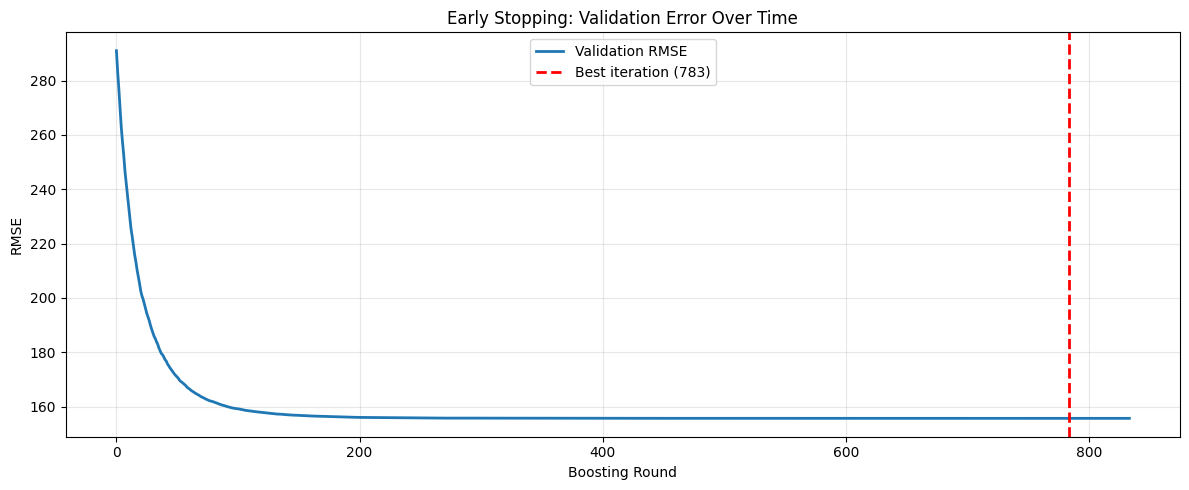


✓ Early stopping prevents overfitting automatically!


In [8]:
print("\n" + "=" * 60)
print("EARLY STOPPING DEMONSTRATION")
print("=" * 60)

# WHAT IS EARLY STOPPING?
# Normally you must decide upfront how many trees to train.
# Too few → underfitting. Too many → overfitting (model memorizes training data).
#
# Early stopping automates this: we keep training until the validation score
# stops improving. If it hasn't improved in N rounds, we stop and roll back
# to the best iteration.
#
# This saves time AND helps generalization — we don't overtrain.

# ── WITHOUT early stopping ──────────────────────────────────────
# We tell it to train 1000 trees no matter what.
print("\nWithout Early Stopping:")
xgb_no_early = xgb.XGBRegressor(
    n_estimators=1000,   # train ALL 1000 trees, no matter the validation score
    learning_rate=0.1,
    max_depth=6,         # deeper trees → more prone to overfitting
    random_state=42
)

xgb_no_early.fit(X_train, y_train)

no_early_train = xgb_no_early.score(X_train, y_train)
no_early_val = xgb_no_early.score(X_val, y_val)

print(f"Used all 1000 trees")
print(f"Train R²: {no_early_train:.4f}")
print(f"Val R²: {no_early_val:.4f}")
print(f"Gap: {no_early_train - no_early_val:.4f}")  # large gap = overfitting

# ── WITH early stopping ─────────────────────────────────────────
# We set a high budget (1000 trees) but let XGBoost stop early
# if validation performance hasn't improved in 50 rounds.
print("\n" + "=" * 60)
print("With Early Stopping:")
print("=" * 60)

xgb_early = xgb.XGBRegressor(
    n_estimators=1000,         # upper bound — we won't necessarily use all of them
    learning_rate=0.1,
    max_depth=6,
    early_stopping_rounds=50,  # stop if no val improvement for 50 consecutive trees
    random_state=42
)

xgb_early.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],  # XGBoost monitors this set to decide when to stop
    verbose=False
)

early_train = xgb_early.score(X_train, y_train)
early_val = xgb_early.score(X_val, y_val)

# best_iteration is where XGBoost stopped (before the 50-round patience expired).
print(f"Stopped at tree: {xgb_early.best_iteration}")
print(f"Train R²: {early_train:.4f}")
print(f"Val R²: {early_val:.4f}")
print(f"Gap: {early_train - early_val:.4f}")  # smaller gap = less overfitting

print("\n" + "=" * 60)
print("EARLY STOPPING BENEFITS:")
print("=" * 60)
print(f"""
Without early stopping:
  • Used all {xgb_no_early.n_estimators} trees
  • Gap: {no_early_train - no_early_val:.4f}
  • May have overfit

With early stopping:
  • Stopped at tree {xgb_early.best_iteration}
  • Gap: {early_train - early_val:.4f}
  • Better generalization!
  
Saved {xgb_no_early.n_estimators - xgb_early.best_iteration} unnecessary trees!
""")

# ── VISUALIZATION ───────────────────────────────────────────────
# Plot the validation RMSE across all training rounds.
# The red dashed line marks where early stopping kicked in.
# Notice how the error decreases, hits a minimum, then would start rising
# again (overfitting) if we kept going — early stopping catches this.

results = xgb_early.evals_result()
train_scores = results['validation_0']['rmse']

plt.figure(figsize=(12, 5))

plt.plot(train_scores, label='Validation RMSE', linewidth=2)
plt.axvline(x=xgb_early.best_iteration, color='red', linestyle='--', 
            linewidth=2, label=f'Best iteration ({xgb_early.best_iteration})')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.title('Early Stopping: Validation Error Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Early stopping prevents overfitting automatically!")

In [9]:
print("\n" + "=" * 60)
print("XGBOOST FOR CLASSIFICATION")
print("=" * 60)

# So far we've only done REGRESSION (predicting continuous numbers like house prices).
# XGBoost also handles CLASSIFICATION — predicting which category something belongs to.
# We just swap XGBRegressor for XGBClassifier. The API is identical.
#
# For binary classification (two classes: 0 or 1), XGBoost internally uses
# a "logistic" objective — it outputs a probability between 0 and 1,
# then assigns the label 0 or 1 based on a threshold (usually 0.5).

from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, roc_auc_score

# make_classification creates a dataset designed for binary classification.
# n_informative=15: 15 of the 20 features are actually predictive.
# n_redundant=5: 5 features are noisy combinations of the informative ones.
X_clf, y_clf = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# XGBClassifier — drop-in replacement for XGBRegressor in classification tasks.
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train_clf, y_train_clf)

# predict() → hard class labels (0 or 1)
# predict_proba() → probability of each class; [:, 1] = probability of class 1
y_pred = xgb_clf.predict(X_test_clf)
y_proba = xgb_clf.predict_proba(X_test_clf)[:, 1]

# METRICS EXPLAINED:
#   Accuracy: % of predictions that were correct overall.
#   Precision: of all samples predicted as class 1, how many really were?
#   Recall: of all actual class 1 samples, how many did we catch?
#   F1-score: harmonic mean of precision and recall — good single summary.
#   ROC AUC: area under the ROC curve — measures discrimination ability
#            (0.5 = random guessing, 1.0 = perfect). Threshold-independent.

train_acc = xgb_clf.score(X_train_clf, y_train_clf)
test_acc = xgb_clf.score(X_test_clf, y_test_clf)
auc = roc_auc_score(y_test_clf, y_proba)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"ROC AUC: {auc:.4f}")  # above 0.9 is generally considered excellent

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred))

# FEATURE IMPORTANCE
# XGBoost tracks how often each feature was used to split a node across all trees.
# Features used more often (and that reduce error more) get higher importance scores.
# This is useful for understanding which inputs drive the model's decisions.
importances = xgb_clf.feature_importances_
top_features = np.argsort(importances)[-10:][::-1]  # top 10 indices, sorted descending

print("\nTop 10 Features:")
for i, idx in enumerate(top_features):
    print(f"  {i+1}. Feature {idx}: {importances[idx]:.4f}")

print("\n✓ XGBoost works for classification too!")


XGBOOST FOR CLASSIFICATION
Train Accuracy: 0.9669
Test Accuracy: 0.9125
ROC AUC: 0.9682

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       207
           1       0.91      0.91      0.91       193

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400


Top 10 Features:
  1. Feature 1: 0.1465
  2. Feature 15: 0.0682
  3. Feature 11: 0.0635
  4. Feature 17: 0.0634
  5. Feature 12: 0.0571
  6. Feature 6: 0.0570
  7. Feature 14: 0.0525
  8. Feature 18: 0.0524
  9. Feature 19: 0.0480
  10. Feature 5: 0.0468

✓ XGBoost works for classification too!


In [10]:
print("\n" + "=" * 60)
print("XGBOOST vs RANDOM FOREST: DECISION GUIDE")
print("=" * 60)

# After all this exploration, when should you actually pick each one?
# Here's a practical guide based on the tradeoffs we've seen.

decision_guide = """
┌─────────────────────────────────────────────────┐
│      WHEN TO USE RANDOM FOREST                  │
├─────────────────────────────────────────────────┤
│                                                 │
│  ✓ Need quick baseline (fast training)          │
│  ✓ Don't want to tune much (works out-of-box)  │
│  ✓ Want stable feature importance               │
│  ✓ Parallel training matters                    │
│  ✓ Less risk of overfitting                     │
│  ✓ Interpretability important (see all trees)   │
│                                                 │
│  Example scenarios:                             │
│  • Prototyping phase                            │
│  • Need model ASAP                              │
│  • Feature selection task                       │
│  • Teaching/learning ML                         │
│                                                 │
└─────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────┐
│      WHEN TO USE XGBOOST                        │
├─────────────────────────────────────────────────┤
│                                                 │
│  ✓ Need maximum accuracy (competitions)         │
│  ✓ Can afford tuning time                      │
│  ✓ Production inference speed matters           │
│  ✓ Want regularization control                 │
│  ✓ Early stopping needed                        │
│  ✓ Have computational resources                 │
│                                                 │
│  Example scenarios:                             │
│  • Kaggle competitions                          │
│  • Production models (millions of predictions)  │
│  • Final model after experimentation            │
│  • Need that extra 1-2% accuracy                │
│                                                 │
└─────────────────────────────────────────────────┘

PRACTICAL WORKFLOW:
1. Start with Random Forest (quick baseline)
2. If accuracy not good enough → Try XGBoost
3. Tune XGBoost carefully
4. If XGBoost only 1% better → Stick with RF (simpler)
5. If XGBoost 3%+ better → Use XGBoost (worth complexity)

KEY INSIGHT:
  Neither model is universally better — the right choice depends
  on your constraints (time, accuracy, interpretability).
  In practice, try both and let the data decide.
"""

print(decision_guide)


XGBOOST vs RANDOM FOREST: DECISION GUIDE

┌─────────────────────────────────────────────────┐
│      WHEN TO USE RANDOM FOREST                  │
├─────────────────────────────────────────────────┤
│                                                 │
│  ✓ Need quick baseline (fast training)          │
│  ✓ Don't want to tune much (works out-of-box)  │
│  ✓ Want stable feature importance               │
│  ✓ Parallel training matters                    │
│  ✓ Less risk of overfitting                     │
│  ✓ Interpretability important (see all trees)   │
│                                                 │
│  Example scenarios:                             │
│  • Prototyping phase                            │
│  • Need model ASAP                              │
│  • Feature selection task                       │
│  • Teaching/learning ML                         │
│                                                 │
└─────────────────────────────────────────────────┘

┌────────────────────

In [ ]:
# ============================================
# COMPLETE XGBOOST PIPELINE
# ============================================
# This is a reusable template for applying XGBoost to any regression problem.
# Follow the steps top to bottom. Replace load_data() with your own data source.

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ============================================
# 1. LOAD & PREPARE DATA
# ============================================
# Replace load_data() with however you actually load your dataset
# (e.g., pd.read_csv(), a database query, a sklearn toy dataset, etc.)

X, y = load_data()

print(f"Samples: {len(X)}, Features: {X.shape[1]}")
print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")

# Three-way split: 70% train, 15% validation, 15% test.
# Validation guides tuning decisions. Test is touched exactly once at the end.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# ============================================
# 2. BASELINE MODEL
# ============================================
# Always establish a baseline first. If the baseline is already great,
# you may not need to tune at all — saving significant time.

print("\n" + "=" * 60)
print("BASELINE MODEL")
print("=" * 60)

xgb_baseline = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

xgb_baseline.fit(X_train, y_train)

baseline_train = xgb_baseline.score(X_train, y_train)
baseline_val = xgb_baseline.score(X_val, y_val)

print(f"Train R²: {baseline_train:.4f}")
print(f"Val R²: {baseline_val:.4f}")
print(f"Gap: {baseline_train - baseline_val:.4f}")

# ============================================
# 3. TUNE CORE PARAMETERS
# ============================================
# GridSearchCV exhaustively tries every combination in param_grid,
# using cross-validation to get a reliable estimate of each combo's performance.
# Larger grids = longer search but more thorough exploration.

print("\n" + "=" * 60)
print("TUNING CORE PARAMETERS")
print("=" * 60)

param_grid_core = {
    'n_estimators': [100, 200, 300],   # more trees = more rounds of correction
    'learning_rate': [0.01, 0.1, 0.3], # step size per tree
    'max_depth': [3, 4, 6]             # tree depth (complexity)
}

grid_core = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_grid_core,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid_core.fit(X_train, y_train)

print(f"\nBest params: {grid_core.best_params_}")
print(f"Best CV R²: {grid_core.best_score_:.4f}")

core_train = grid_core.score(X_train, y_train)
core_val = grid_core.score(X_val, y_val)
gap = core_train - core_val

print(f"Train R²: {core_train:.4f}")
print(f"Val R²: {core_val:.4f}")
print(f"Gap: {gap:.4f}")

# ============================================
# 4. ADD REGULARIZATION (If needed)
# ============================================
# If train score >> val score (gap > 5%), the model is overfitting.
# Regularization limits how aggressively the model fits training data.
#
# RandomizedSearchCV is like GridSearchCV but instead of trying every
# combination, it randomly samples n_iter combinations. Much faster for
# large parameter spaces (5 params × 3 values = 243 combos; random search
# can explore this space with far fewer evaluations).

if gap > 0.05:
    print("\n" + "=" * 60)
    print("ADDING REGULARIZATION (Gap > 5%)")
    print("=" * 60)
    
    param_grid_reg = {
        'subsample': [0.7, 0.8, 0.9],          # fraction of rows per tree
        'colsample_bytree': [0.7, 0.8, 0.9],   # fraction of features per tree
        'min_child_weight': [1, 3, 5],          # min samples required in a leaf
        'reg_alpha': [0, 0.1, 1.0],             # L1 regularization (lasso-like)
        'reg_lambda': [1, 2, 5]                 # L2 regularization (ridge-like)
    }
    
    # Lock in the best core params and search over regularization on top.
    xgb_with_core = xgb.XGBRegressor(
        **grid_core.best_params_,
        random_state=42,
        n_jobs=-1
    )
    
    random_reg = RandomizedSearchCV(
        xgb_with_core,
        param_grid_reg,
        n_iter=30,       # try 30 random combinations instead of all 243
        cv=3,
        scoring='r2',
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    
    random_reg.fit(X_train, y_train)
    
    print(f"\nBest regularization: {random_reg.best_params_}")
    
    tuned_model = random_reg.best_estimator_
else:
    print("\nGap < 5% - Regularization not needed")
    tuned_model = grid_core.best_estimator_

# ============================================
# 5. EARLY STOPPING REFINEMENT
# ============================================
# Take the tuned hyperparameters and let early stopping find the
# optimal n_estimators automatically — no more guessing!
# We set n_estimators very high (10000) as an upper limit,
# then rely on the validation set to tell us when to stop.

print("\n" + "=" * 60)
print("EARLY STOPPING REFINEMENT")
print("=" * 60)

final_params = tuned_model.get_params()
final_params['n_estimators'] = 10000          # generous upper limit
final_params['early_stopping_rounds'] = 50    # stop if no improvement for 50 rounds

xgb_final = xgb.XGBRegressor(**final_params)

xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],   # monitor validation score during training
    verbose=False
)

print(f"Stopped at iteration: {xgb_final.best_iteration}")
print(f"Used {xgb_final.best_iteration} trees (instead of 10000)")

# ============================================
# 6. FINAL EVALUATION
# ============================================
# This is the moment of truth — evaluate on the test set.
# Because we never used test data during tuning, this score is
# an unbiased estimate of real-world performance.

print("\n" + "=" * 60)
print("FINAL MODEL EVALUATION")
print("=" * 60)

final_train = xgb_final.score(X_train, y_train)
final_val = xgb_final.score(X_val, y_val)
final_test = xgb_final.score(X_test, y_test)

y_pred_test = xgb_final.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))  # in same units as target

print(f"\nFinal Parameters:")
print(f"  n_estimators: {xgb_final.best_iteration}")
print(f"  learning_rate: {xgb_final.learning_rate}")
print(f"  max_depth: {xgb_final.max_depth}")

print(f"\nPerformance:")
print(f"  Train R²: {final_train:.4f}")
print(f"  Val R²: {final_val:.4f}")
print(f"  Test R²: {final_test:.4f}")
print(f"  Test RMSE: {rmse:.4f}")
print(f"  Gap (train-val): {final_train - final_val:.4f}")

# ============================================
# 7. FEATURE IMPORTANCE
# ============================================
# Which features did the model rely on most?
# High importance → that feature strongly influenced predictions.
# Low importance → consider removing it to simplify the model.

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

importances = xgb_final.feature_importances_
top_indices = np.argsort(importances)[-10:][::-1]  # top 10 in descending order

print("\nTop 10 Features:")
for i, idx in enumerate(top_indices):
    print(f"  {i+1}. Feature {idx}: {importances[idx]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: XGBoost's built-in importance bar chart (top 10 features).
xgb.plot_importance(xgb_final, max_num_features=10, ax=ax1)
ax1.set_title('Top 10 Feature Importances')

# Right: validation RMSE curve with early stopping marker.
# Shows how the model improved over rounds and where it stopped.
results = xgb_final.evals_result()
train_metric = list(results['validation_0'].values())[0]

ax2.plot(train_metric, label='Validation Score', linewidth=2)
ax2.axvline(x=xgb_final.best_iteration, color='red', linestyle='--',
            label=f'Best iteration ({xgb_final.best_iteration})')
ax2.set_xlabel('Boosting Round')
ax2.set_ylabel('Score')
ax2.set_title('Training Progress (Early Stopping)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 8. SAVE MODEL
# ============================================
# XGBoost can save/load models in JSON format — compact and portable.
# Always save both the model and key metadata (hyperparams, metrics)
# so you can reproduce or audit results later.

print("\n" + "=" * 60)
print("SAVING MODEL")
print("=" * 60)

xgb_final.save_model('xgboost_model.json')
print("✓ Model saved to: xgboost_model.json")

metadata = {
    'n_estimators': xgb_final.best_iteration,
    'learning_rate': float(xgb_final.learning_rate),
    'max_depth': int(xgb_final.max_depth),
    'test_r2': float(final_test),
    'test_rmse': float(rmse),
    'n_features': X.shape[1],
    'feature_importances': importances.tolist()
}

import json
with open('xgboost_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✓ Metadata saved to: xgboost_metadata.json")

# ============================================
# 9. LOAD AND USE (Later)
# ============================================
# Loading is just two lines — create an empty model then load the saved file.
# The loaded model behaves exactly like the original.

loaded_model = xgb.XGBRegressor()
loaded_model.load_model('xgboost_model.json')

# Replace X_new with your actual new data when deploying.
new_predictions = loaded_model.predict(X_new)

print("\n✓ Complete XGBoost pipeline finished!")